#quiz2

step1 : 下載並認識資料庫

In [1]:
import pandas as pd

file_path = "data/UCI_Credit_Card.csv"

df = pd.read_csv(file_path)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [2]:
print("資料筆數、欄位數：", df.shape)

資料筆數、欄位數： (30000, 25)


In [3]:
print(df.columns)

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [5]:
print(df.isnull().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


Step 2：準備 X 與 Y

In [6]:
# Step 2：準備 X 與 Y

X = df.drop(columns=["ID", "default.payment.next.month"])
y = df["default.payment.next.month"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 23)
y shape: (30000,)


Step 3：切分 Training Dataset / Validation Dataset

In [7]:
# Step 3：切分 Training Dataset / Validation Dataset

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (24000, 23)
X_val: (6000, 23)
y_train: (24000,)
y_val: (6000,)


Step 4：Feature Scaling

In [8]:
# Step 4：Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)

X_train_scaled shape: (24000, 23)
X_val_scaled shape: (6000, 23)


Step 5：觀察 Feature Scaling 前後

In [9]:
print("Scaling 前：")
print(X_train.iloc[:5, :5])

print("\nScaling 後：")
print(X_train_scaled[:5, :5])

Scaling 前：
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE
22788   160000.0    2          2         2   33
29006   150000.0    2          1         2   34
16950    10000.0    1          2         1   50
22280   220000.0    2          1         2   29
11346   310000.0    2          1         2   32

Scaling 後：
[[-0.05686623  0.80844039  0.18452304  0.85673912 -0.26455769]
 [-0.13408117  0.80844039 -1.07753249  0.85673912 -0.15580369]
 [-1.21509034 -1.23694958  0.18452304 -1.05936739  1.58426024]
 [ 0.40642341  0.80844039 -1.07753249  0.85673912 -0.69957367]
 [ 1.10135788  0.80844039 -1.07753249  0.85673912 -0.37331168]]


In [11]:
# Step 6：建立 MLP

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(23,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

Step 7：設定 Loss Function、Optimizer、Learning Rate

In [12]:
# Step 7：設定 Loss Function、Optimizer、Learning Rate

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Step 8：設定 Epoch、Batch Size 並訓練模型

In [13]:
# Step 8：設定 Epoch、Batch Size 並訓練模型

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8083 - loss: 0.4681 - val_accuracy: 0.8145 - val_loss: 0.4523
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8190 - loss: 0.4412 - val_accuracy: 0.8162 - val_loss: 0.4438
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8201 - loss: 0.4351 - val_accuracy: 0.8175 - val_loss: 0.4411
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8204 - loss: 0.4305 - val_accuracy: 0.8167 - val_loss: 0.4375
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8217 - loss: 0.4285 - val_accuracy: 0.8175 - val_loss: 0.4397
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8210 - loss: 0.4269 - val_accuracy: 0.8198 - val_loss: 0.4421
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8223 - loss: 0.4252 - val_accuracy: 0.8163 - val_loss: 0.4429
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8222 - loss: 0.4242 - val_accuracy: 0.

Step 9：繪製 Training Loss / Validation Loss

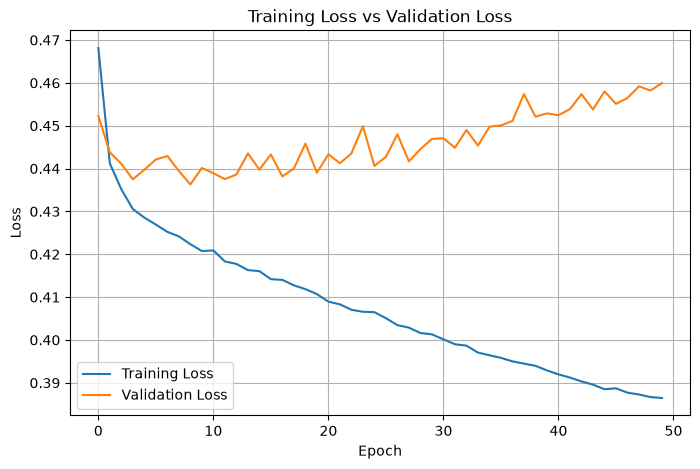

In [14]:
# Step 9：繪製 Training Loss / Validation Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

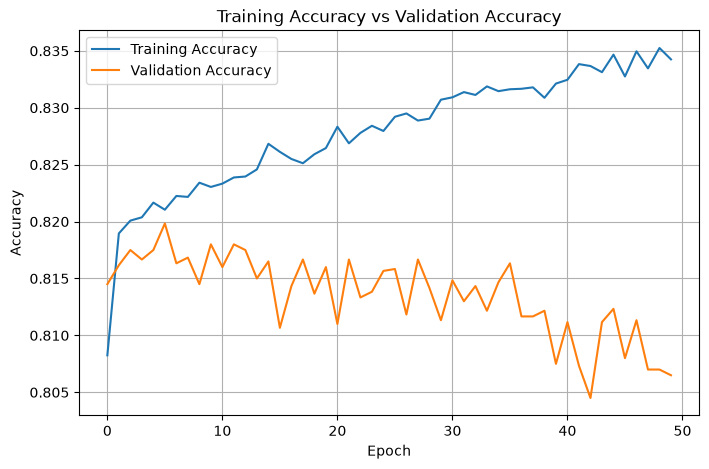

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

Step 10：使用 Validation Dataset 預測

In [17]:
# Step 10：預測 Validation Dataset 的一筆 Sample

sample = X_val_scaled[0].reshape(1, -1)

prediction = model.predict(sample)

print("預測機率：", prediction[0][0])
print("實際答案：", y_val.iloc[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
預測機率： 0.16179445
實際答案： 0


Step 11：設定 Threshold 並取得預測結果

In [18]:
# Step 11：Threshold

threshold = 0.5

predicted_class = (prediction[0][0] >= threshold).astype(int)

print("預測機率：", prediction[0][0])
print("Threshold：", threshold)
print("預測結果：", predicted_class)
print("實際答案：", y_val.iloc[0])

預測機率： 0.16179445
Threshold： 0.5
預測結果： 0
實際答案： 0


Step 12：預測全部 Validation Dataset

In [19]:
# Step 12：預測全部 Validation Dataset

y_val_prob = model.predict(X_val_scaled)

threshold = 0.5

y_val_pred = (y_val_prob >= threshold).astype(int)

print("預測機率 shape：", y_val_prob.shape)
print("預測結果 shape：", y_val_pred.shape)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step
預測機率 shape： (6000, 1)
預測結果 shape： (6000, 1)


Step 13：Confusion Matrix + Accuracy / Precision / Recall / F1-Score

In [20]:
# Step 13：Confusion Matrix + 評估指標

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 將預測結果轉成一維
y_val_pred = y_val_pred.ravel()

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)

# 評估指標
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("\nEvaluation Metrics:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Confusion Matrix:
[[4340  333]
 [ 828  499]]

Evaluation Metrics:
Accuracy : 0.8065
Precision: 0.5997596153846154
Recall   : 0.3760361718161266
F1-Score : 0.46225104214914314


Step 14：進階——改善模型-建立加入 Dropout 的 MLP

In [21]:
# Step 14：進階——加入 Dropout 改善模型

from tensorflow.keras.layers import Input, Dense, Dropout

model_dropout = Sequential([
    Input(shape=(23,)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_dropout.summary()

model_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)